In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
import cv2
import seaborn as sns

In [40]:
image = cv2.imread('cr.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

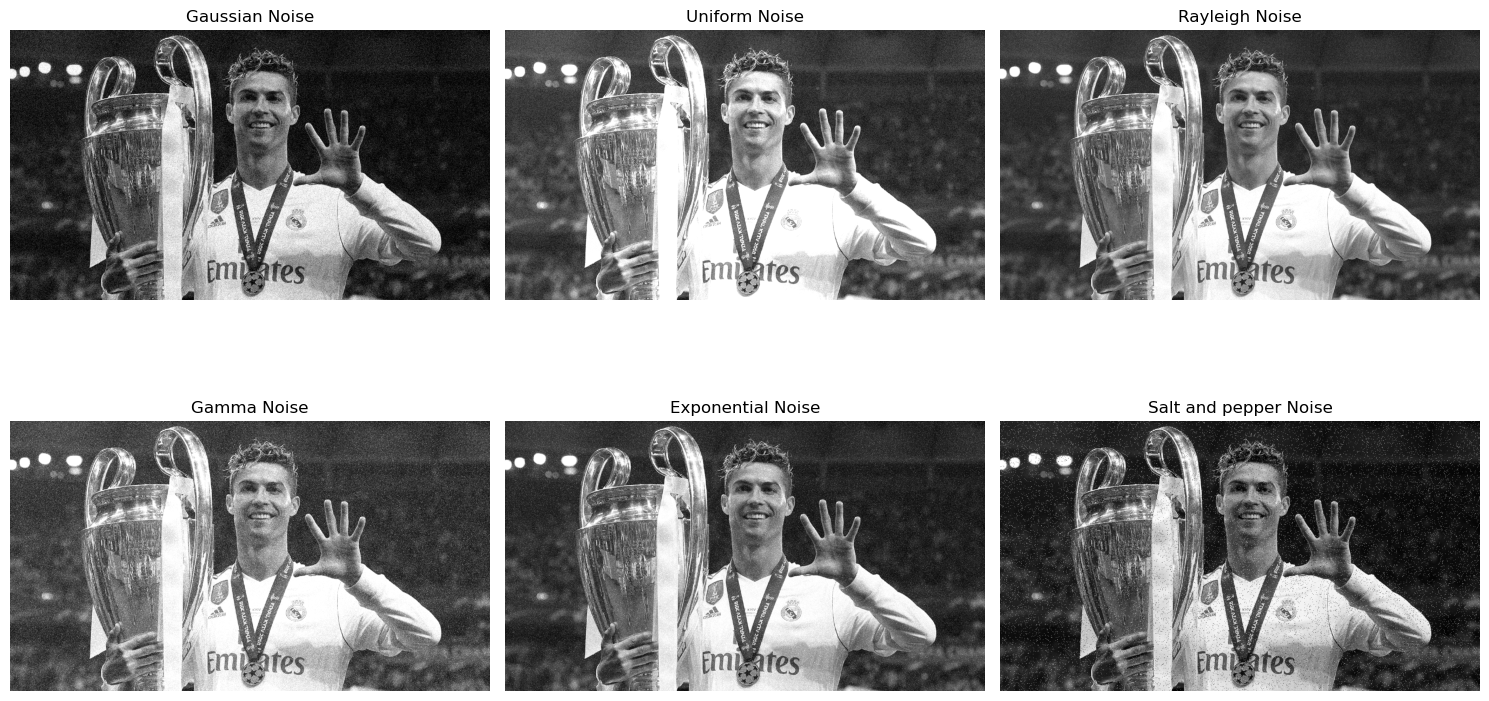

In [35]:
plt.figure(figsize=(15, 9))

def add_noise(image, method, idx, mean=0, std=25, low=50, high=100, scale=20, shape=2, noise_ratio=0.05):
    noisy_image = image.copy()
    
    if method == "gaussian":
        noise = np.random.normal(mean, std, image.shape)
        noisy_image = image + noise
    elif method == "rayleigh":
        noise = np.random.rayleigh(scale, image.shape)
        noisy_image = image + noise
    elif method == "gamma":
        noise = np.random.gamma(shape, scale, image.shape)
        noisy_image = image + noise
    elif method == "exponential":
        noise = np.random.exponential(scale, image.shape)
        noisy_image = image + noise
    elif method == "uniform":
        noise = np.random.uniform(low, high, image.shape)
        noisy_image = image + noise
    elif method == "salt and pepper":
        noisy_image = impulse(image, noise_ratio)
    else:
        print("Invalid Noise method")
        return image
    
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
    
    plt.subplot(2, 3, idx)
    plt.imshow(noisy_image, cmap='gray')
    plt.title(f"{method.capitalize()} Noise")
    plt.axis('off')
    
    return noisy_image

def impulse(image, noise_ratio):
    noisy_image = image.copy()
    h, w = noisy_image.shape
    noisy_pixels = int(h * w * noise_ratio)
    
    for _ in range(noisy_pixels):
        row, col = np.random.randint(0, h), np.random.randint(0, w)
        noisy_image[row, col] = 0 if np.random.rand() < 0.5 else 255
    
    return noisy_image

n_img = add_noise(image, 'gaussian', idx=1)
u_img = add_noise(image, 'uniform', idx=2)
r_img = add_noise(image, 'rayleigh', idx=3)
g_img = add_noise(image, 'gamma', idx=4)
e_img = add_noise(image, 'exponential', idx=5)
i_img = add_noise(image, 'salt and pepper', idx=6)

plt.tight_layout()
plt.show()

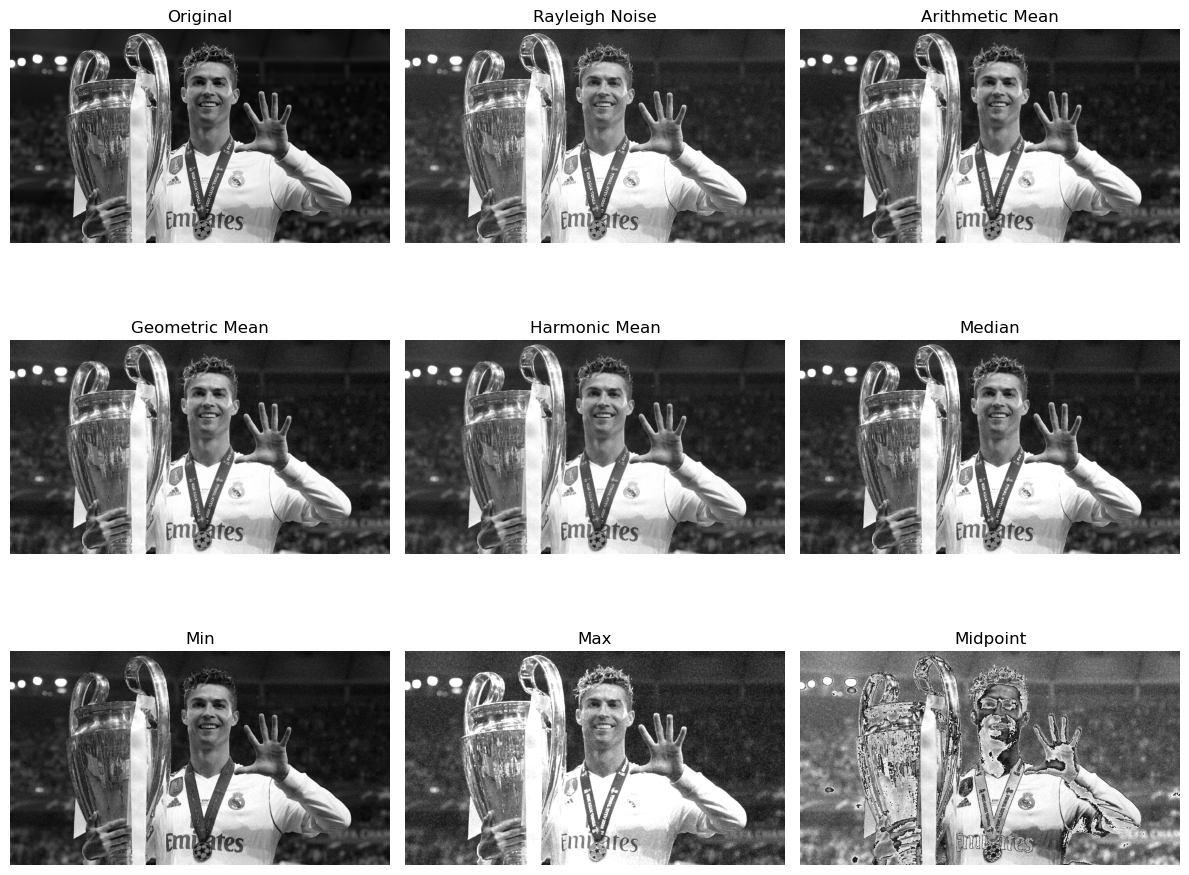

In [37]:
from scipy.ndimage import generic_filter


def arithmetic_mean_filter(img, size=3):
    kernel = np.ones((size, size), dtype=np.float32) / (size * size)
    return cv2.filter2D(img, -1, kernel)

# Geometric Mean Filter
def geometric_mean_filter(img, size=3):
    def geo_mean(window):
        window = window[window > 0]  # Avoid log(0)
        return np.exp(np.mean(np.log(window))) if len(window) > 0 else 1  # Prevent NaN
    return generic_filter(img.astype(np.float32), geo_mean, size=(size, size)).astype(np.uint8)

# Harmonic Mean Filter
def harmonic_mean_filter(img, size=3):
    def harm_mean(window):
        window = window[window > 0]  # Avoid division by zero
        return len(window) / np.sum(1.0 / window) if np.any(window > 0) else 1  # Prevent NaN
    return generic_filter(img.astype(np.float32), harm_mean, size=(size, size)).astype(np.uint8)

# Median Filter
def median_filter(img, size=3):
    return cv2.medianBlur(img, size)

# Min Filter
def min_filter(img, size=3):
    return cv2.erode(img, np.ones((size, size), np.uint8))

# Max Filter
def max_filter(img, size=3):
    return cv2.dilate(img, np.ones((size, size), np.uint8))

# Midpoint Filter
def midpoint_filter(img, size=3):
    max_filt = max_filter(img, size)
    min_filt = min_filter(img, size)
    return ((max_filt + min_filt) / 2).astype(np.uint8)

# Load and Preprocess Image
img = cv2.imread(r"cr.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY )
if img is None:
    raise ValueError("Error: Image not found or unable to load. Check the file path!")

# Apply Rayleigh Noise
noisy_img = r_img

# Apply Restoration Filters
arith_mean = arithmetic_mean_filter(noisy_img)
geo_mean = geometric_mean_filter(noisy_img)
harm_mean = harmonic_mean_filter(noisy_img)
median_filt = median_filter(noisy_img)
min_filt = min_filter(noisy_img)
max_filt = max_filter(noisy_img)
midpoint_filt = midpoint_filter(noisy_img)

# Titles for Display
img_title = ['Original', 'Rayleigh Noise', 'Arithmetic Mean', 'Geometric Mean', 
             'Harmonic Mean', 'Median', 'Min', 'Max', 'Midpoint']

# Images List
images = [img, noisy_img, arith_mean, geo_mean, harm_mean, 
          median_filt, min_filt, max_filt, midpoint_filt]

# Plot Images
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, im, title in zip(axes.flat, images, img_title):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [38]:
def sobel_filter(img):
    kernelx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    kernely = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    gx = np.zeros_like(img, dtype=np.int64)
    gy = np.zeros_like(img, dtype=np.int64)
    padded_img = cv2.copyMakeBorder(img,1,1,1,1, cv2.BORDER_REFLECT)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            win = padded_img[i:i+3, j:j+3]
            gx[i, j] = np.sum(win * kernelx)
            gy[i, j] = np.sum(win * kernely)
    result_img = np.hypot(gx, gy)
    result_img = np.clip(result_img, 0, 255)
    return result_img.astype(np.uint8)

(-0.5, 1295.5, 728.5, -0.5)

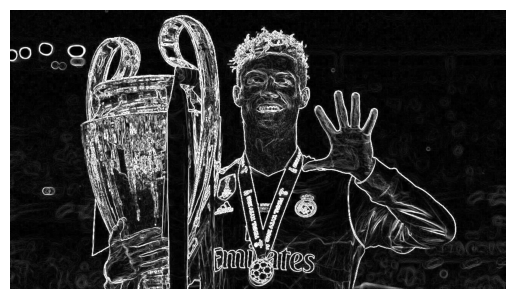

In [39]:
plt.imshow(sobel_filter(image),cmap='gray')
plt.axis("off")